In [1]:
import numpy as np
import os
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("⚙️ Restarting the Engine: Loading Data & Imbalance Fixes...")

# 1. Define Paths
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# 2. Re-calculate the Mathematical Class Weights (The Imbalance Fix)
classes = sorted(os.listdir(train_dir))
image_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
num_classes = len(classes)

weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.arange(num_classes), 
    y=np.repeat(np.arange(num_classes), image_counts)
)

# Convert to pure Python dictionary to prevent JSON crash later
class_weights_dict = dict(zip(np.arange(num_classes), weights))
pure_class_weights = {int(k): float(v) for k, v in class_weights_dict.items()}
print("✅ Class weights re-calculated safely.")

# 3. Re-initialize the Real-Time Augmentation Pipelines
train_datagen = ImageDataGenerator(
    rescale=1./255,          
    rotation_range=20,       
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    zoom_range=0.1,          
    horizontal_flip=True,    
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 4. Connect Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True 
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

print("\n🚀 Engine Ready. You can now build the Hybrid Model!")

⚙️ Restarting the Engine: Loading Data & Imbalance Fixes...
✅ Class weights re-calculated safely.
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.

🚀 Engine Ready. You can now build the Hybrid Model!


C:\Users\shiha\AppData\Local\Temp\ipykernel_19644\1098719507.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df, palette='viridis')


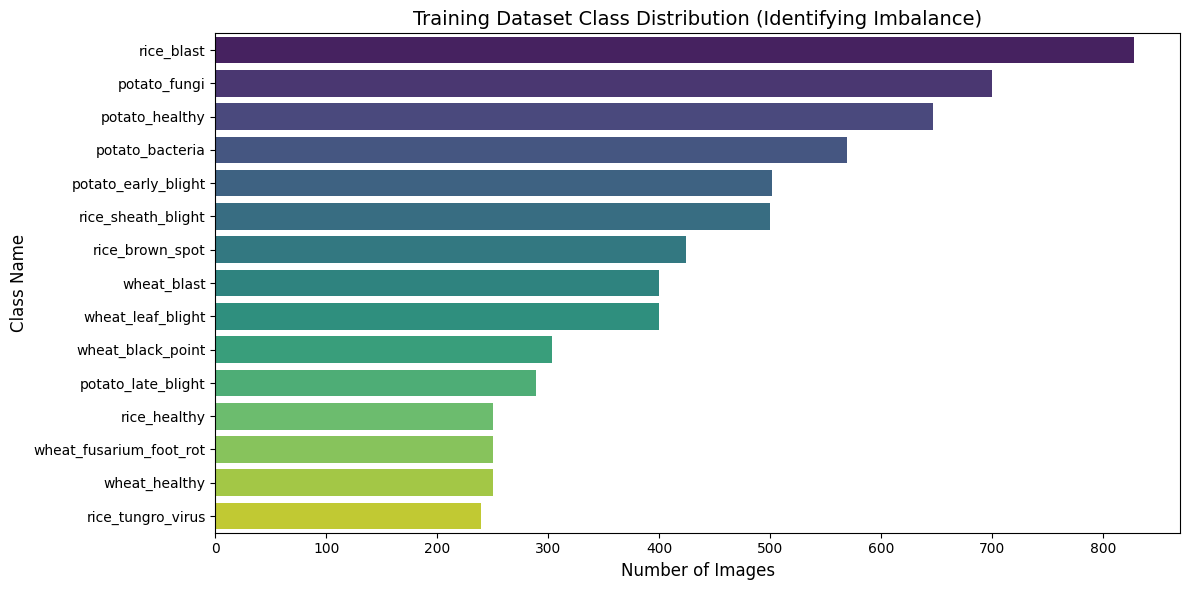

--- Raw Training Data Counts ---
          Disease Class  Image Count
             rice_blast          828
           potato_fungi          700
         potato_healthy          647
        potato_bacteria          569
    potato_early_blight          502
     rice_sheath_blight          500
        rice_brown_spot          424
            wheat_blast          400
      wheat_leaf_blight          400
      wheat_black_point          303
     potato_late_blight          289
           rice_healthy          250
wheat_fusarium_foot_rot          250
          wheat_healthy          250
      rice_tungro_virus          239


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the path to your training data
train_dir = r"D:\00" 

# 2. Count images in each class
classes = os.listdir(train_dir)
image_counts = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    count = len(os.listdir(class_path))
    image_counts.append(count)

# 3. Create a table (DataFrame) for easy viewing and plotting
df = pd.DataFrame({'Disease Class': classes, 'Image Count': image_counts})
df = df.sort_values(by='Image Count', ascending=False)

# 4. Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Image Count', y='Disease Class', data=df, palette='viridis')
plt.title('Training Dataset Class Distribution (Identifying Imbalance)', fontsize=14)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class Name', fontsize=12)
plt.tight_layout()

# Save the plot so you can put it in your thesis document later
plt.savefig(r"D:\00_Final_Split\class_distribution_chart.png")
plt.show()

# 5. Print the raw numbers for documentation
print("--- Raw Training Data Counts ---")
print(df.to_string(index=False))

In [3]:
import os
import pandas as pd

# The absolute beginning: Your main raw dataset folder
main_dataset_path = r"D:\00"

print(f"📂 Auditing raw dataset at: {main_dataset_path}\n")

# Get all class folders
classes = sorted(os.listdir(main_dataset_path))
total_images = 0
data_info = []

print("--- Original Dataset Breakdown ---")
for cls in classes:
    folder_path = os.path.join(main_dataset_path, cls)
    
    # Count only the image files inside each folder
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        data_info.append({'Class': cls, 'Count': count})
        total_images += count
        print(f" -> {cls}: {count} images")

print("-" * 35)
print(f"Total Disease Classes: {len(classes)}")
print(f"Total Raw Images: {total_images}")

# Optional: Find the biggest and smallest classes to highlight the imbalance mathematically
counts = [item['Count'] for item in data_info]
print(f"\n⚠️ Imbalance Check:")
print(f"Largest class has {max(counts)} images.")
print(f"Smallest class has {min(counts)} images.")

📂 Auditing raw dataset at: D:\00

--- Original Dataset Breakdown ---
 -> potato_bacteria: 569 images
 -> potato_early_blight: 502 images
 -> potato_fungi: 700 images
 -> potato_healthy: 647 images
 -> potato_late_blight: 289 images
 -> rice_blast: 828 images
 -> rice_brown_spot: 424 images
 -> rice_healthy: 250 images
 -> rice_sheath_blight: 500 images
 -> rice_tungro_virus: 239 images
 -> wheat_black_point: 303 images
 -> wheat_blast: 400 images
 -> wheat_fusarium_foot_rot: 250 images
 -> wheat_healthy: 250 images
 -> wheat_leaf_blight: 400 images
-----------------------------------
Total Disease Classes: 15
Total Raw Images: 6551

⚠️ Imbalance Check:
Largest class has 828 images.
Smallest class has 239 images.


In [1]:
import splitfolders
import os

# 1. Define Paths
input_folder = r"D:\00"
output_folder = r"D:\00_Thesis_Split" # Brand new, clean folder

print(f"✂️ Starting Stratified Split from {input_folder}...")
print(f"Creating new directories in {output_folder}...")

# 2. Execute the Split (80% Train, 10% Val, 10% Test)
# seed=42 ensures that if you run this again, it splits exactly the same way (reproducibility)
splitfolders.ratio(
    input_folder, 
    output=output_folder, 
    seed=42, 
    ratio=(0.8, 0.1, 0.1), 
    group_prefix=None, 
    move=False # We copy the files, keeping your original D:\00 completely safe
)

print("\n✅ Splitting Complete!")

# 3. Verify the newly created folders
train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

def count_files(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        total += len(files)
    return total

print("-" * 35)
print("--- New Dataset Verification ---")
print(f"Training Images: {count_files(train_dir)}")
print(f"Validation Images: {count_files(val_dir)}")
print(f"Testing Images: {count_files(test_dir)}")
print("Data Leakage Risk: ELIMINATED.")

✂️ Starting Stratified Split from D:\00...
Creating new directories in D:\00_Thesis_Split...

✅ Splitting Complete!
-----------------------------------
--- New Dataset Verification ---
Training Images: 5238
Validation Images: 650
Testing Images: 663
Data Leakage Risk: ELIMINATED.


In [2]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧬 Building True Hybrid Architecture 1: DenseNet121 + MobileNetV2...")

# 1. The Shared Input (Image goes in here)
shared_input = Input(shape=(224, 224, 3), name="hybrid_input")

# 2. Brain 1: DenseNet121 (Frozen)
base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers:
    layer._name = layer.name + str("_dense") # Prevents naming crashes!
base_dense.trainable = False
features_dense = GlobalAveragePooling2D()(base_dense.output)

# 3. Brain 2: MobileNetV2 (Frozen)
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mobile.layers:
    layer._name = layer.name + str("_mobile") # Prevents naming crashes!
base_mobile.trainable = False
features_mobile = GlobalAveragePooling2D()(base_mobile.output)

# 4. THE HYBRID CONNECTION: Feature Concatenation
print("🔗 Fusing feature maps...")
combined_features = Concatenate(name="feature_fusion")([features_dense, features_mobile])

# 5. The Master Head (Learning how to combine the two streams)
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions = Dense(15, activation='softmax', name="final_output")(x)

# 6. Finalize the Hybrid Model
hybrid_model_1 = Model(inputs=shared_input, outputs=hybrid_predictions)

# 7. Compile the Model
pure_class_weights = {int(k): float(v) for k, v in class_weights_dict.items()}

hybrid_model_1.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])

# 8. Setup Callbacks (Saving weights only to avoid JSON bugs)
checkpoint_hybrid = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_Weights.h5", 
    save_weights_only=True, 
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_hybrid = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hybrid = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# 9. Train the Hybrid!
print("\n🚀 Starting Training: Hybrid Model 1 (DenseNet + MobileNet)")
history_hybrid_1 = hybrid_model_1.fit(
    train_generator,
    epochs=20, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid, early_stop_hybrid, reduce_lr_hybrid],
    verbose=1
)

print("\n✅ Hybrid Model 1 Training Complete.")

🧬 Building True Hybrid Architecture 1: DenseNet121 + MobileNetV2...
🔗 Fusing feature maps...

🚀 Starting Training: Hybrid Model 1 (DenseNet + MobileNet)
Epoch 1/20
328/328 [==============================] - ETA: 0s - loss: 1.0283 - accuracy: 0.6861
Epoch 1: val_accuracy improved from -inf to 0.84769, saving model to D:\00_Thesis_Split\Hybrid1_Dense_Mobile_Weights.h5
328/328 [==============================] - 143s 389ms/step - loss: 1.0283 - accuracy: 0.6861 - val_loss: 0.3920 - val_accuracy: 0.8477 - lr: 0.0010
Epoch 2/20
328/328 [==============================] - ETA: 0s - loss: 0.5383 - accuracy: 0.8137
Epoch 2: val_accuracy improved from 0.84769 to 0.87538, saving model to D:\00_Thesis_Split\Hybrid1_Dense_Mobile_Weights.h5
328/328 [==============================] - 103s 315ms/step - loss: 0.5383 - accuracy: 0.8137 - val_loss: 0.3410 - val_accuracy: 0.8754 - lr: 0.0010
Epoch 3/20
328/328 [==============================] - ETA: 0s - loss: 0.4399 - accuracy: 0.8381
Epoch 3: val_accurac

In [3]:
print("⚡ Phase 2: Unfreezing the Hybrid Model (Fine-Tuning)...")

# 1. Load the absolute best weights from Phase 1
hybrid_model_1.load_weights(r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_Weights.h5")

# 2. UNFREEZE BOTH BASE MODELS
# Now the entire massive architecture will learn together
base_dense.trainable = True
base_mobile.trainable = True

# 3. Re-compile with a VERY SLOW learning rate (1e-5)
# A fast rate here would cause catastrophic forgetting and destroy both models
hybrid_model_1.compile(optimizer=Adam(learning_rate=1e-5), 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])

# 4. Setup Callbacks for Phase 2
checkpoint_hybrid_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_FineTuned_Weights.h5", 
    save_weights_only=True,
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_hybrid_fine = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 5. Train the Unfrozen Hybrid
print("\n🚀 Starting Fine-Tuning: Hybrid Model 1")
history_hybrid_1_fine = hybrid_model_1.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid_fine, early_stop_hybrid_fine],
    verbose=1
)

print("\n✅ Hybrid Model 1 Fine-Tuning Complete.")

⚡ Phase 2: Unfreezing the Hybrid Model (Fine-Tuning)...

🚀 Starting Fine-Tuning: Hybrid Model 1
Epoch 1/15


ResourceExhaustedError: Graph execution error:

Detected at node 'model/conv3_block7_concat_dense/concat' defined at (most recent call last):
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
      app.start()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    File "c:\Users\shiha\miniconda3\envs\tf_gpu\lib\site-packages\tornado\platform\asyncio.py", line 211, in start
      self.asyncio_loop.run_forever()
    File "c:\User

In [4]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 Clearing GPU VRAM from the crash...")
tf.keras.backend.clear_session()

# 1. THE FIX: Lower Batch Size to save GPU Memory
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
NEW_BATCH_SIZE = 8  # <--- Halved from 16 to 8!

print("♻️ Rebuilding Data Generators with Batch Size 8...")
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=NEW_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=NEW_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Rebuild the Hybrid Architecture (Since we cleared the session)
print("🏗️ Rebuilding Hybrid Architecture...")
shared_input = Input(shape=(224, 224, 3), name="hybrid_input")

base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
features_dense = GlobalAveragePooling2D()(base_dense.output)

base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mobile.layers: layer._name = layer.name + str("_mobile")
features_mobile = GlobalAveragePooling2D()(base_mobile.output)

combined_features = Concatenate(name="feature_fusion")([features_dense, features_mobile])

x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions = Dense(15, activation='softmax', name="final_output")(x)

hybrid_model_1 = Model(inputs=shared_input, outputs=hybrid_predictions)

# 3. Load the 90%+ Phase 1 Weights
print("🧠 Loading saved Phase 1 brain power...")
hybrid_model_1.load_weights(r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_Weights.h5")

# 4. UNFREEZE for Phase 2
print("🔓 Unfreezing both models for Fine-Tuning...")
base_dense.trainable = True
base_mobile.trainable = True

hybrid_model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_hybrid_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_FineTuned_Weights.h5", 
    save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1
)
early_stop_hybrid_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# 5. Resume Training!
print("\n🚀 Starting Fine-Tuning: Hybrid Model 1 (Batch Size 8)")
history_hybrid_1_fine = hybrid_model_1.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, # Uses the weights still in your computer's memory
    callbacks=[checkpoint_hybrid_fine, early_stop_hybrid_fine],
    verbose=1
)

🧹 Clearing GPU VRAM from the crash...
♻️ Rebuilding Data Generators with Batch Size 8...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
🏗️ Rebuilding Hybrid Architecture...
🧠 Loading saved Phase 1 brain power...
🔓 Unfreezing both models for Fine-Tuning...

🚀 Starting Fine-Tuning: Hybrid Model 1 (Batch Size 8)
Epoch 1/15
655/655 [==============================] - ETA: 0s - loss: 0.5367 - accuracy: 0.8097
Epoch 1: val_accuracy improved from -inf to 0.91846, saving model to D:\00_Thesis_Split\Hybrid1_Dense_Mobile_FineTuned_Weights.h5
655/655 [==============================] - 167s 225ms/step - loss: 0.5367 - accuracy: 0.8097 - val_loss: 0.2405 - val_accuracy: 0.9185
Epoch 2/15
655/655 [==============================] - ETA: 0s - loss: 0.3946 - accuracy: 0.8507
Epoch 2: val_accuracy improved from 0.91846 to 0.92154, saving model to D:\00_Thesis_Split\Hybrid1_Dense_Mobile_FineTuned_Weights.h5
655/655 [==============================] - 152s 232ms/step - 

📝 Initiating Final Exam & Visuals for Hybrid Model 1...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
83/83 [==============================] - 12s 134ms/step - loss: 0.1625 - accuracy: 0.9351

🏆 Hybrid 1 (DenseNet + MobileNet) Unbiased Test Accuracy: 93.51%
🔍 Generating detailed predictions...
83/83 [==============================] - 10s 124ms/step

--- Thesis Documentation: Hybrid 1 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.97      0.97      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.96      0.93      0.94        70
         potato_healthy       0.96      0.97      0.96        66
     potato_late_blight       0.97      1.00      0.98        30
             rice_blast       0.85      0.81      0.83        84
        rice_brown_spot       0.85      0.81      0.83        43
           rice_healthy       0.81  

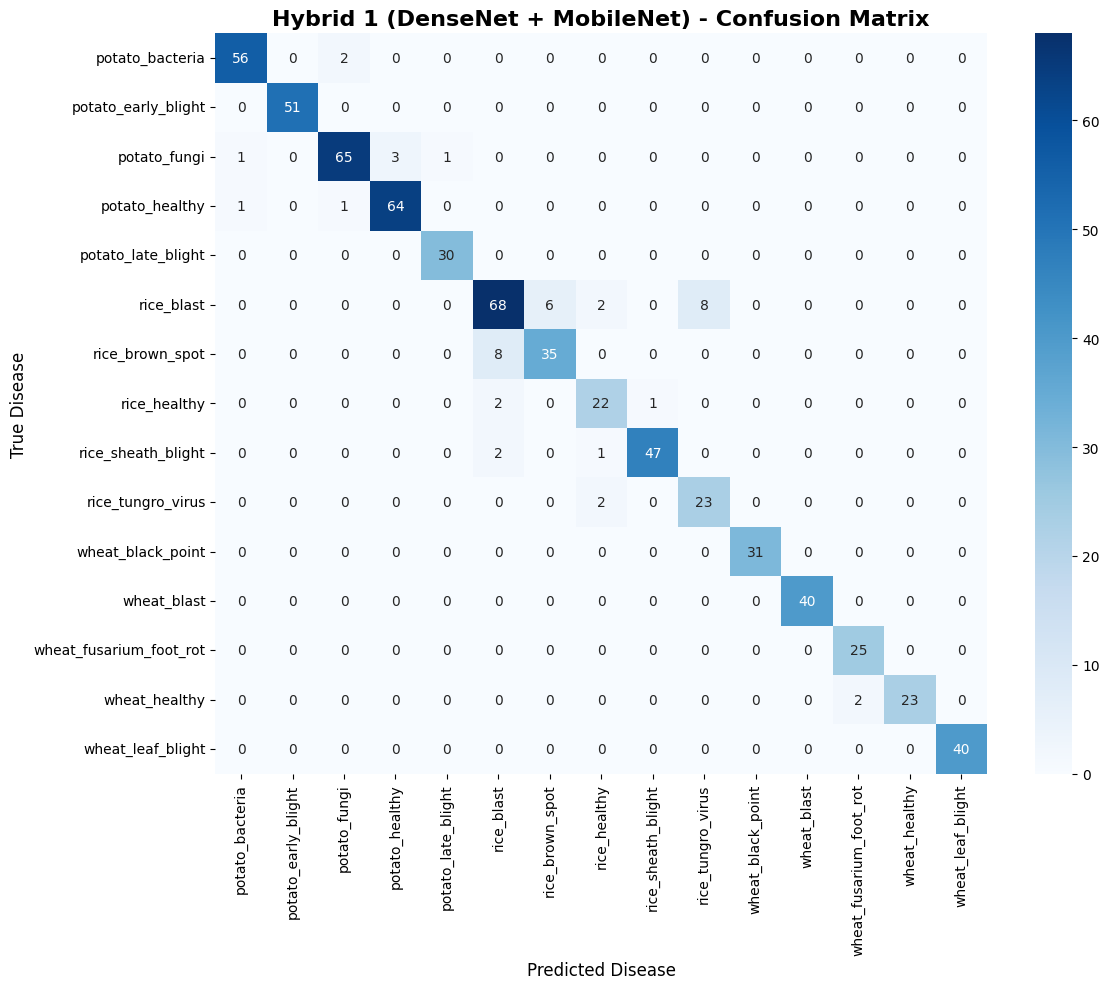

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📝 Initiating Final Exam & Visuals for Hybrid Model 1...")

# 1. Rebuild Test Generator (Batch Size 8 for GPU safety)
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 8 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best weights from Phase 2 (Epoch 10)
hybrid_model_1.load_weights(r"D:\00_Thesis_Split\Hybrid1_Dense_Mobile_FineTuned_Weights.h5")

# 3. Get overall Accuracy
print("\n📊 Running standard evaluation...")
test_loss_hybrid, test_acc_hybrid = hybrid_model_1.evaluate(test_generator, verbose=1)
print(f"\n🏆 Hybrid 1 (DenseNet + MobileNet) Unbiased Test Accuracy: {test_acc_hybrid * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hybrid = hybrid_model_1.predict(test_generator, verbose=1)
y_pred_hybrid = np.argmax(predictions_hybrid, axis=1)
y_true_hybrid = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 1 Classification Report ---")
print(classification_report(y_true_hybrid, y_pred_hybrid, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hybrid = confusion_matrix(y_true_hybrid, y_pred_hybrid)
sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 1 (DenseNet + MobileNet) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\Hybrid1_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\Hybrid1_Confusion_Matrix.png")
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧬 Building True Hybrid Architecture 2: DenseNet121 + EfficientNetB0...")

# 1. The Shared Input
shared_input = Input(shape=(224, 224, 3), name="hybrid2_input")

# 2. Brain 1: DenseNet121 (Frozen)
base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: 
    layer._name = layer.name + str("_dense") # Crucial for avoiding naming crashes!
base_dense.trainable = False
features_dense = GlobalAveragePooling2D()(base_dense.output)

# 3. Brain 2: EfficientNetB0 (Frozen)
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: 
    layer._name = layer.name + str("_eff")
base_eff.trainable = False
features_eff = GlobalAveragePooling2D()(base_eff.output)

# 4. THE HYBRID CONNECTION
print("🔗 Fusing feature maps...")
combined_features = Concatenate(name="feature_fusion_2")([features_dense, features_eff])

# 5. The Master Head
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions_2 = Dense(15, activation='softmax', name="final_output_2")(x)

# 6. Finalize the Hybrid Model
hybrid_model_2 = Model(inputs=shared_input, outputs=hybrid_predictions_2)

# 7. Compile the Model
pure_class_weights = {int(k): float(v) for k, v in class_weights_dict.items()}

hybrid_model_2.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])

# 8. Setup Callbacks
checkpoint_hybrid_2 = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid2_Dense_Eff_Weights.h5", 
    save_weights_only=True, 
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_hybrid_2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hybrid_2 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# 9. Train Phase 1!
print("\n🚀 Starting Training: Hybrid Model 2 (DenseNet + EfficientNet)")
history_hybrid_2 = hybrid_model_2.fit(
    train_generator, # Still securely using Batch Size 8 from earlier!
    epochs=20, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid_2, early_stop_hybrid_2, reduce_lr_hybrid_2],
    verbose=1
)

print("\n✅ Hybrid Model 2 (Phase 1) Training Complete.")

🧬 Building True Hybrid Architecture 2: DenseNet121 + EfficientNetB0...
🔗 Fusing feature maps...

🚀 Starting Training: Hybrid Model 2 (DenseNet + EfficientNet)
Epoch 1/20
655/655 [==============================] - ETA: 0s - loss: 1.5741 - accuracy: 0.5315
Epoch 1: val_accuracy improved from -inf to 0.82462, saving model to D:\00_Thesis_Split\Hybrid2_Dense_Eff_Weights.h5
655/655 [==============================] - 208s 289ms/step - loss: 1.5741 - accuracy: 0.5315 - val_loss: 0.5467 - val_accuracy: 0.8246 - lr: 0.0010
Epoch 2/20
655/655 [==============================] - ETA: 0s - loss: 0.8608 - accuracy: 0.6921
Epoch 2: val_accuracy improved from 0.82462 to 0.82769, saving model to D:\00_Thesis_Split\Hybrid2_Dense_Eff_Weights.h5
655/655 [==============================] - 173s 263ms/step - loss: 0.8608 - accuracy: 0.6921 - val_loss: 0.4780 - val_accuracy: 0.8277 - lr: 0.0010
Epoch 3/20
655/655 [==============================] - ETA: 0s - loss: 0.6887 - accuracy: 0.7367
Epoch 3: val_accurac

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 Clearing GPU VRAM from the EfficientNet crash...")
tf.keras.backend.clear_session()

# 1. THE EXTREME FIX: Lower Batch Size to 4
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
EXTREME_BATCH_SIZE = 4  # <--- Halved again!

print("♻️ Rebuilding Data Generators with Batch Size 4...")
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=EXTREME_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=EXTREME_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Rebuild the Hybrid 2 Architecture
print("🏗️ Rebuilding Hybrid Architecture 2 (DenseNet + EfficientNet)...")
shared_input = Input(shape=(224, 224, 3), name="hybrid2_input")

base_dense = DenseNet121(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_dense.layers: layer._name = layer.name + str("_dense")
features_dense = GlobalAveragePooling2D()(base_dense.output)

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + str("_eff")
features_eff = GlobalAveragePooling2D()(base_eff.output)

combined_features = Concatenate(name="feature_fusion_2")([features_dense, features_eff])

x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions_2 = Dense(15, activation='softmax', name="final_output_2")(x)

hybrid_model_2 = Model(inputs=shared_input, outputs=hybrid_predictions_2)

# 3. Load the 93.38% Phase 1 Weights
print("🧠 Loading saved Phase 1 brain power...")
hybrid_model_2.load_weights(r"D:\00_Thesis_Split\Hybrid2_Dense_Eff_Weights.h5")

# 4. UNFREEZE for Phase 2
print("🔓 Unfreezing both models for Fine-Tuning...")
base_dense.trainable = True
base_eff.trainable = True

hybrid_model_2.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_hybrid_2_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid2_Dense_Eff_FineTuned_Weights.h5", 
    save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1
)
early_stop_hybrid_2_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# 5. Resume Training!
print("\n🚀 Starting Fine-Tuning: Hybrid Model 2 (Batch Size 4)")
history_hybrid_2_fine = hybrid_model_2.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid_2_fine, early_stop_hybrid_2_fine],
    verbose=1
)

🧹 Clearing GPU VRAM from the EfficientNet crash...
♻️ Rebuilding Data Generators with Batch Size 4...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
🏗️ Rebuilding Hybrid Architecture 2 (DenseNet + EfficientNet)...
🧠 Loading saved Phase 1 brain power...
🔓 Unfreezing both models for Fine-Tuning...

🚀 Starting Fine-Tuning: Hybrid Model 2 (Batch Size 4)
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 0.8033 - accuracy: 0.7331
Epoch 1: val_accuracy improved from -inf to 0.87538, saving model to D:\00_Thesis_Split\Hybrid2_Dense_Eff_FineTuned_Weights.h5
1310/1310 [==============================] - 355s 230ms/step - loss: 0.8033 - accuracy: 0.7331 - val_loss: 0.3354 - val_accuracy: 0.8754
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 0.5495 - accuracy: 0.8032
Epoch 2: val_accuracy improved from 0.87538 to 0.89231, saving model to D:\00_Thesis_Split\Hybrid2_Dense_Eff_FineTuned_Weights.h5
1310/1310 [=========

📝 Initiating Final Exam & Visuals for Hybrid Model 2 (DenseNet + EfficientNet)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
166/166 [==============================] - 14s 80ms/step - loss: 0.2046 - accuracy: 0.9321

🏆 Hybrid 2 (DenseNet + EfficientNet) Unbiased Test Accuracy: 93.21%
🔍 Generating detailed predictions...
166/166 [==============================] - 13s 51ms/step

--- Thesis Documentation: Hybrid 2 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.97      0.97      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.97      0.87      0.92        70
         potato_healthy       0.89      1.00      0.94        66
     potato_late_blight       1.00      0.97      0.98        30
             rice_blast       0.87      0.80      0.83        84
        rice_brown_spot       0.94      0.79      0.86        43
     

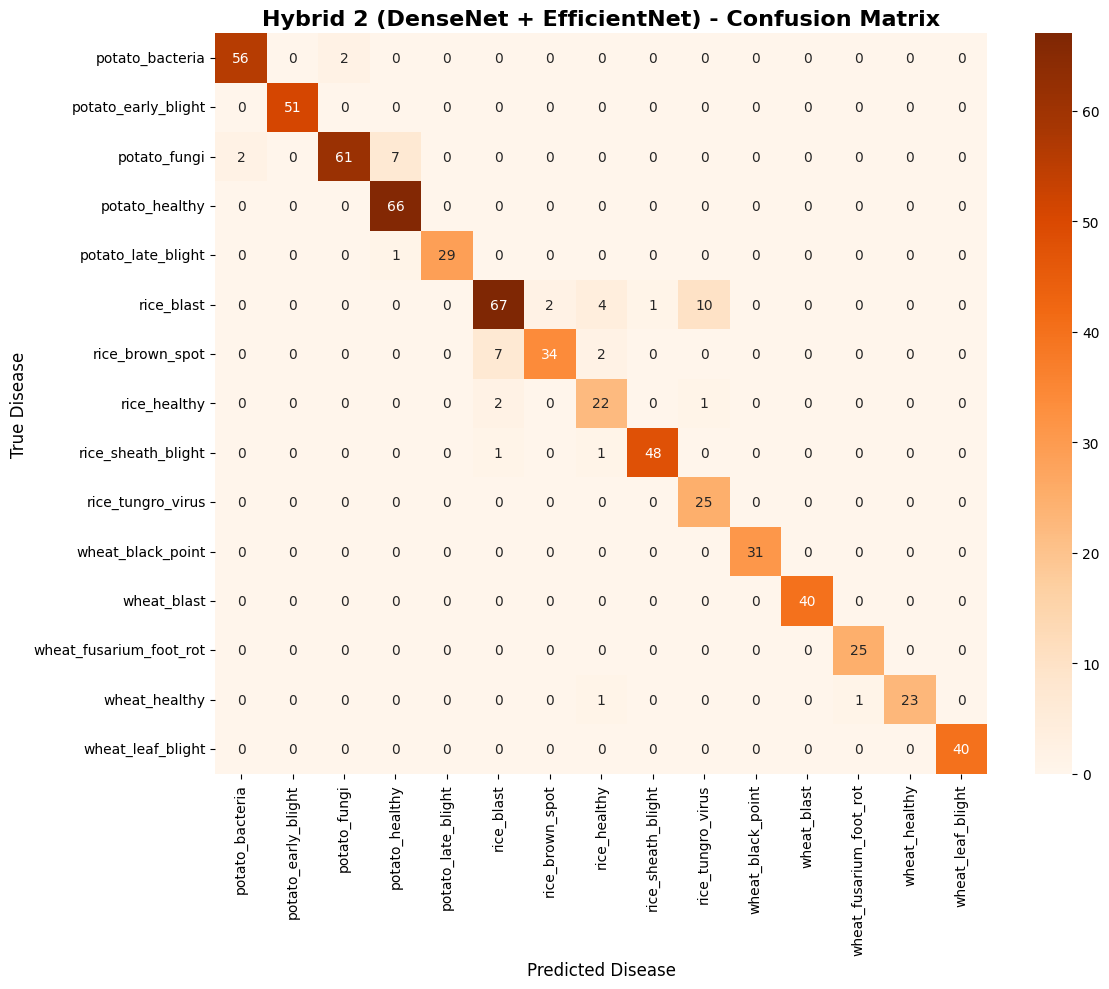

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📝 Initiating Final Exam & Visuals for Hybrid Model 2 (DenseNet + EfficientNet)...")

# 1. Rebuild Test Generator (Keeping Batch Size 4 for absolute safety)
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best weights from Phase 2
hybrid_model_2.load_weights(r"D:\00_Thesis_Split\Hybrid2_Dense_Eff_FineTuned_Weights.h5")

# 3. Get overall Accuracy
print("\n📊 Running standard evaluation...")
test_loss_hybrid2, test_acc_hybrid2 = hybrid_model_2.evaluate(test_generator, verbose=1)
print(f"\n🏆 Hybrid 2 (DenseNet + EfficientNet) Unbiased Test Accuracy: {test_acc_hybrid2 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hybrid2 = hybrid_model_2.predict(test_generator, verbose=1)
y_pred_hybrid2 = np.argmax(predictions_hybrid2, axis=1)
y_true_hybrid2 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 2 Classification Report ---")
print(classification_report(y_true_hybrid2, y_pred_hybrid2, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hybrid2 = confusion_matrix(y_true_hybrid2, y_pred_hybrid2)
sns.heatmap(cm_hybrid2, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 2 (DenseNet + EfficientNet) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\Hybrid2_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\Hybrid2_Confusion_Matrix.png")
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🧬 Building True Hybrid Architecture 3: MobileNetV2 + EfficientNetB0...")

# 1. The Shared Input
shared_input = Input(shape=(224, 224, 3), name="hybrid3_input")

# 2. Brain 1: MobileNetV2 (Frozen)
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mobile.layers: 
    layer._name = layer.name + str("_mob3") # Preventing crashes!
base_mobile.trainable = False
features_mobile = GlobalAveragePooling2D()(base_mobile.output)

# 3. Brain 2: EfficientNetB0 (Frozen)
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: 
    layer._name = layer.name + str("_eff3")
base_eff.trainable = False
features_eff = GlobalAveragePooling2D()(base_eff.output)

# 4. THE HYBRID CONNECTION
print("🔗 Fusing lightweight feature maps...")
combined_features = Concatenate(name="feature_fusion_3")([features_mobile, features_eff])

# 5. The Master Head
x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions_3 = Dense(15, activation='softmax', name="final_output_3")(x)

# 6. Finalize the Hybrid Model
hybrid_model_3 = Model(inputs=shared_input, outputs=hybrid_predictions_3)

# 7. Compile the Model
pure_class_weights = {int(k): float(v) for k, v in class_weights_dict.items()}

hybrid_model_3.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])

# 8. Setup Callbacks
checkpoint_hybrid_3 = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid3_Mobile_Eff_Weights.h5", 
    save_weights_only=True, 
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_hybrid_3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr_hybrid_3 = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

# 9. Train Phase 1!
print("\n🚀 Starting Training: Hybrid Model 3 (MobileNet + EfficientNet)")
history_hybrid_3 = hybrid_model_3.fit(
    train_generator, # Still using Batch Size 4 from memory!
    epochs=20, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid_3, early_stop_hybrid_3, reduce_lr_hybrid_3],
    verbose=1
)

print("\n✅ Hybrid Model 3 (Phase 1) Training Complete.")

🧬 Building True Hybrid Architecture 3: MobileNetV2 + EfficientNetB0...
🔗 Fusing lightweight feature maps...

🚀 Starting Training: Hybrid Model 3 (MobileNet + EfficientNet)
Epoch 1/20
328/328 [==============================] - ETA: 0s - loss: 1.4777 - accuracy: 0.5697
Epoch 1: val_accuracy improved from -inf to 0.80154, saving model to D:\00_Thesis_Split\Hybrid3_Mobile_Eff_Weights.h5
328/328 [==============================] - 283s 789ms/step - loss: 1.4777 - accuracy: 0.5697 - val_loss: 0.5875 - val_accuracy: 0.8015 - lr: 0.0010
Epoch 2/20
328/328 [==============================] - ETA: 0s - loss: 0.8358 - accuracy: 0.7119
Epoch 2: val_accuracy improved from 0.80154 to 0.81538, saving model to D:\00_Thesis_Split\Hybrid3_Mobile_Eff_Weights.h5
328/328 [==============================] - 172s 522ms/step - loss: 0.8358 - accuracy: 0.7119 - val_loss: 0.4911 - val_accuracy: 0.8154 - lr: 0.0010
Epoch 3/20
328/328 [==============================] - ETA: 0s - loss: 0.6952 - accuracy: 0.7461
Epoch

In [6]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("🧹 Clearing GPU VRAM from the Hybrid 3 crash...")
tf.keras.backend.clear_session()

# 1. THE STRICT FIX: Force Batch Size back to 4!
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
STRICT_BATCH_SIZE = 4 

print("♻️ Rebuilding Data Generators with strict Batch Size 4...")
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.1,   
    height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=STRICT_BATCH_SIZE, class_mode='categorical', shuffle=True 
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=STRICT_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Rebuild the Hybrid Architecture 3 (MobileNet + EfficientNet)
print("🏗️ Rebuilding Hybrid Architecture 3...")
shared_input = Input(shape=(224, 224, 3), name="hybrid3_input")

base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_mobile.layers: layer._name = layer.name + str("_mob3")
features_mobile = GlobalAveragePooling2D()(base_mobile.output)

base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=shared_input)
for layer in base_eff.layers: layer._name = layer.name + str("_eff3")
features_eff = GlobalAveragePooling2D()(base_eff.output)

combined_features = Concatenate(name="feature_fusion_3")([features_mobile, features_eff])

x = BatchNormalization()(combined_features)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
hybrid_predictions_3 = Dense(15, activation='softmax', name="final_output_3")(x)

hybrid_model_3 = Model(inputs=shared_input, outputs=hybrid_predictions_3)

# 3. Load the Phase 1 Weights
print("🧠 Loading saved Phase 1 brain power...")
hybrid_model_3.load_weights(r"D:\00_Thesis_Split\Hybrid3_Mobile_Eff_Weights.h5")

# 4. UNFREEZE for Phase 2
print("🔓 Unfreezing both models for Fine-Tuning...")
base_mobile.trainable = True
base_eff.trainable = True

hybrid_model_3.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint_hybrid_3_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\Hybrid3_Mobile_Eff_FineTuned_Weights.h5", 
    save_weights_only=True, save_best_only=True, monitor='val_accuracy', verbose=1
)
early_stop_hybrid_3_fine = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# 5. Resume Training!
print("\n🚀 Starting Fine-Tuning: Hybrid Model 3 (Batch Size 4)")
history_hybrid_3_fine = hybrid_model_3.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_hybrid_3_fine, early_stop_hybrid_3_fine],
    verbose=1
)

🧹 Clearing GPU VRAM from the Hybrid 3 crash...
♻️ Rebuilding Data Generators with strict Batch Size 4...
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.
🏗️ Rebuilding Hybrid Architecture 3...
🧠 Loading saved Phase 1 brain power...
🔓 Unfreezing both models for Fine-Tuning...

🚀 Starting Fine-Tuning: Hybrid Model 3 (Batch Size 4)
Epoch 1/15
1310/1310 [==============================] - ETA: 0s - loss: 1.3668 - accuracy: 0.5953
Epoch 1: val_accuracy improved from -inf to 0.79077, saving model to D:\00_Thesis_Split\Hybrid3_Mobile_Eff_FineTuned_Weights.h5
1310/1310 [==============================] - 233s 156ms/step - loss: 1.3668 - accuracy: 0.5953 - val_loss: 0.7714 - val_accuracy: 0.7908
Epoch 2/15
1310/1310 [==============================] - ETA: 0s - loss: 1.0264 - accuracy: 0.6648
Epoch 2: val_accuracy did not improve from 0.79077
1310/1310 [==============================] - 196s 149ms/step - loss: 1.0264 - accuracy: 0.6648 - val_loss: 0.6939 - val_a

📝 Initiating Final Exam & Visuals for Hybrid Model 3 (MobileNet + EfficientNet)...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
166/166 [==============================] - 8s 45ms/step - loss: 0.4226 - accuracy: 0.8703

🏆 Hybrid 3 (MobileNet + EfficientNet) Unbiased Test Accuracy: 87.03%
🔍 Generating detailed predictions...
166/166 [==============================] - 10s 42ms/step

--- Thesis Documentation: Hybrid 3 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.93      0.98      0.96        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.94      0.87      0.90        70
         potato_healthy       0.90      0.97      0.93        66
     potato_late_blight       1.00      1.00      1.00        30
             rice_blast       0.84      0.55      0.66        84
        rice_brown_spot       0.76      0.81      0.79        43
    

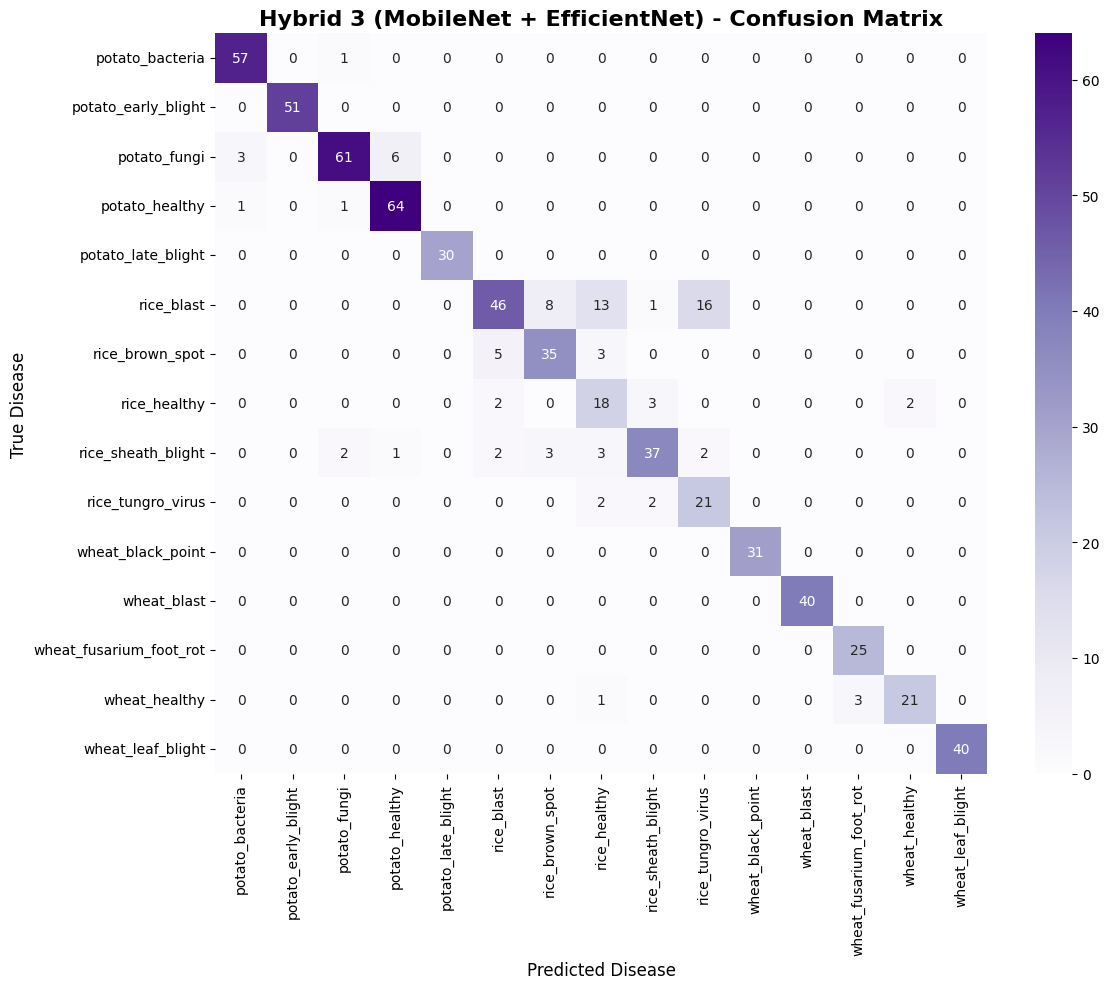

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("📝 Initiating Final Exam & Visuals for Hybrid Model 3 (MobileNet + EfficientNet)...")

# 1. Rebuild Test Generator (Keeping Batch Size 4 for safety)
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
TEST_BATCH_SIZE = 4 

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=TEST_BATCH_SIZE, class_mode='categorical', shuffle=False 
)

# 2. Load the absolute best weights from Phase 2
hybrid_model_3.load_weights(r"D:\00_Thesis_Split\Hybrid3_Mobile_Eff_FineTuned_Weights.h5")

# 3. Get overall Accuracy
print("\n📊 Running standard evaluation...")
test_loss_hybrid3, test_acc_hybrid3 = hybrid_model_3.evaluate(test_generator, verbose=1)
print(f"\n🏆 Hybrid 3 (MobileNet + EfficientNet) Unbiased Test Accuracy: {test_acc_hybrid3 * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("🔍 Generating detailed predictions...")
predictions_hybrid3 = hybrid_model_3.predict(test_generator, verbose=1)
y_pred_hybrid3 = np.argmax(predictions_hybrid3, axis=1)
y_true_hybrid3 = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Hybrid 3 Classification Report ---")
print(classification_report(y_true_hybrid3, y_pred_hybrid3, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_hybrid3 = confusion_matrix(y_true_hybrid3, y_pred_hybrid3)
sns.heatmap(cm_hybrid3, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title('Hybrid 3 (MobileNet + EfficientNet) - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\Hybrid3_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\Hybrid3_Confusion_Matrix.png")
plt.show()